Read data file ~/sandbox/extensions/card-data/aro_index.tsv

**Responding Iteratively**

I need to respond iteratively for clarity. First, I should load the data file and inspect it. I’ll show the shape, columns, and then the head of the DataFrame using code that’s runnable in a notebook. I'll import pandas and read the TSV file with the appropriate separator. It would be best to display the shape and columns before heading to the data preview. I’ll ensure there's no confusion by keeping it concise and organized without multiple final expressions.

Let’s load the TSV into a DataFrame and do the initial inspection only.



In [1]:
import pandas as pd
from IPython.display import display

path = "~/sandbox/extensions/card-data/aro_index.tsv"
df = pd.read_csv(path, sep="\t")

summary = pd.DataFrame({
    "rows": [df.shape[0]],
    "columns": [df.shape[1]]
})
display(summary)

display(pd.DataFrame({"column": df.columns}))

df.head()

,rows,columns
0,6445,12


,column
0,ARO Accession
1,CVTERM ID
2,Model Sequence ID
3,Model ID
4,Model Name
5,ARO Name
6,Protein Accession
7,DNA Accession
8,AMR Gene Family
9,Drug Class


,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id


<!--final answer-->
The file has been read into a pandas DataFrame named `df`.

From the observed notebook state:
- It contains **6445 rows** and **12 columns**.
- The columns are:
  - `ARO Accession`
  - `CVTERM ID`
  - `Model Sequence ID`
  - `Model ID`
  - `Model Name`
  - `ARO Name`
  - `Protein Accession`
  - `DNA Accession`
  - `AMR Gene Family`
  - `Drug Class`
  - `Resistance Mechanism`
  - `CARD Short Name`

The first few records also show this is CARD ARO index data with antibiotic resistance ontology and model metadata, including identifiers, names, gene family, drug class, and resistance mechanism fields.

So the original read step is complete, and the dataset is available in the notebook as `df`.

Read a file ~/sandbox/extensions/card-data/aro_categories_index.tsv

**Loading dataset for inspection**

I need to respond to the user's prompt by using the current notebook state. My first step is to load the dataset and perform some inspection to understand its structure, specifically the shape, columns, and head. Since the user asked to read a file, I should load the new TSV into a new variable, maybe df2 or categories_df, to avoid overwriting the existing dataframe. I think using categories_df is the best route. I’ll keep it concise!

Let’s load the categories index into a new DataFrame so we keep `df` intact, and inspect it.



In [2]:
import pandas as pd
from IPython.display import display

path_categories = "~/sandbox/extensions/card-data/aro_categories_index.tsv"
categories_df = pd.read_csv(path_categories, sep="\t")

summary_categories = pd.DataFrame({
    "rows": [categories_df.shape[0]],
    "columns": [categories_df.shape[1]]
})
display(summary_categories)

display(pd.DataFrame({"column": categories_df.columns}))

categories_df.head()

,rows,columns
0,6402,5


,column
0,Protein Accession
1,DNA Accession
2,AMR Gene Family
3,Drug Class
4,Resistance Mechanism


,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism
0,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration
1,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation
2,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation
3,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation
4,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation


<!--final answer-->
The file `~/sandbox/extensions/card-data/aro_categories_index.tsv` is now available in the notebook as `categories_df`.

From the observed output:
- It has **6402 rows** and **5 columns**.
- The columns are:
  - `Protein Accession`
  - `DNA Accession`
  - `AMR Gene Family`
  - `Drug Class`
  - `Resistance Mechanism`

The sample rows show this file is a category-focused index: each record links protein and DNA accessions to resistance-related annotations such as gene family, drug class, and resistance mechanism. Compared with the broader `aro_index.tsv`, this file does not include ARO/model identifier fields and is more compact, centered on categorical annotation.

In the dataframe loaded from aro_index.tsv, the Drug Class column contains multiple values separated by semicolons. 
Split that column by semicolon, count how many unique genes exist for each drug class, 
and plot a horizontal bar chart showing the top 20 drug classes sorted from most to least genes.

**Formulating data processing code**

I’m thinking about using `replace('', pd.NA).fillna(df['ARO Name'])` as part of my data processing. Then, I’d explode on Drug Class, group by, and use nunique to get unique counts. After that, sorting in descending order and grabbing the top 20 sounds good. I’ll create a horizontal bar chart for better visualization, reversing the order to show the most significant values at the top. I should also set a figure size for clarity before finalizing the code block.

I’ll use `CARD Short Name` as the gene label, and fall back to `ARO Name` when the short name is missing.



<Axes: title={'center': 'Top 20 Drug Classes by Number of Unique Genes'}, xlabel='Number of unique genes', ylabel='Drug Class'>

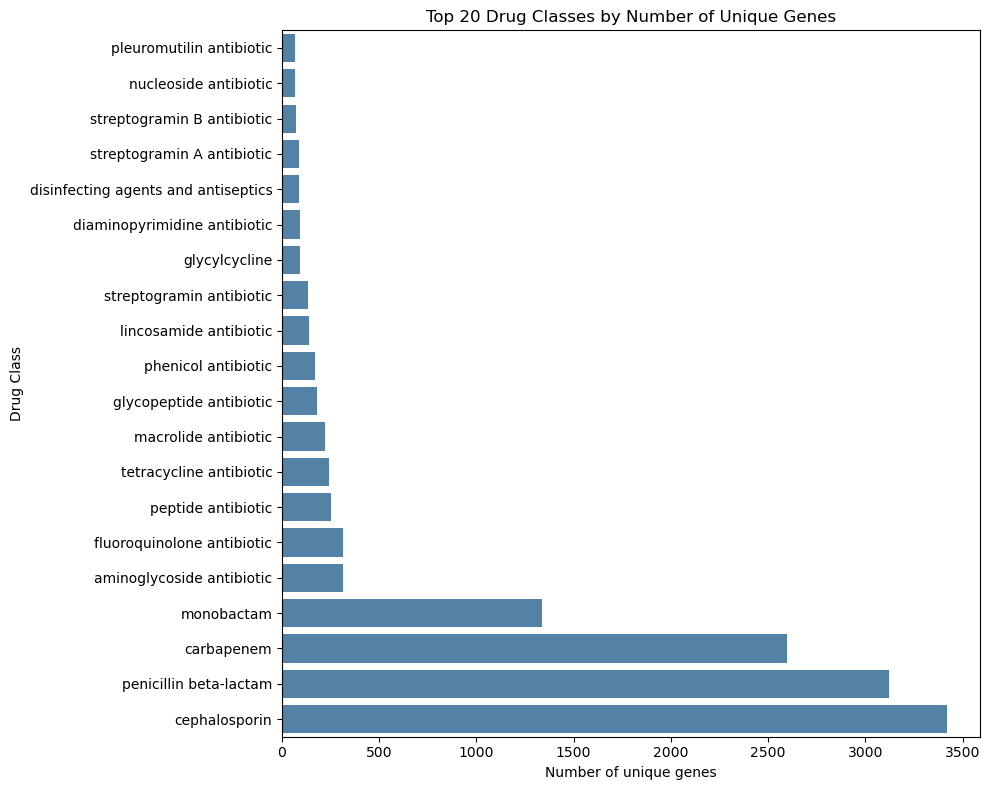

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df.copy()

plot_df["gene_name"] = plot_df["CARD Short Name"].replace("", pd.NA).fillna(plot_df["ARO Name"])

drug_gene_counts = (
    plot_df.assign(**{"Drug Class": plot_df["Drug Class"].fillna("").str.split(";")})
    .explode("Drug Class")
    .assign(**{"Drug Class": lambda x: x["Drug Class"].str.strip()})
    .query("`Drug Class` != ''")
    .groupby("Drug Class")["gene_name"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .sort_values(ascending=True)
    .reset_index(name="unique_genes")
)

plt.figure(figsize=(10, 8))
ax = sns.barplot(data=drug_gene_counts, x="unique_genes", y="Drug Class", color="steelblue")
ax.set_title("Top 20 Drug Classes by Number of Unique Genes")
ax.set_xlabel("Number of unique genes")
ax.set_ylabel("Drug Class")
plt.tight_layout()
ax

The latest output shows the aggregation and plotting step ran successfully: a horizontal bar chart object was created from the split `Drug Class` values and the grouped unique-gene counts. What’s still missing is the ranked value table behind that chart, which is needed to state which drug classes are actually in the top 20 and their counts.



In [4]:
from IPython.display import display

top20_table = drug_gene_counts.sort_values("unique_genes", ascending=False).reset_index(drop=True)
display(top20_table)

,Drug Class,unique_genes
0,cephalosporin,3419
1,penicillin beta-lactam,3123
2,carbapenem,2599
3,monobactam,1339
4,aminoglycoside antibiotic,312
5,fluoroquinolone antibiotic,312
6,peptide antibiotic,254
7,tetracycline antibiotic,242
8,macrolide antibiotic,222
9,glycopeptide antibiotic,178


**Summarizing antibiotic rankings**

I could note that the ranking is led by cephalosporin (3419), penicillin beta-lactam (3123), carbapenem (2599), and monobactam (1339). There’s also a tie at 312 for aminoglycoside and fluoroquinolone. The chart reflects descending counts among the top 20, built by counting unique gene labels from the CARD Short Name, with a fallback to the ARO Name. I should mention the use of this fallback is acceptable given the notebook state. Lastly, I’ll ensure to include a concise summary sign-off.

<!--final answer-->

The requested result is now reflected in the notebook outputs: the `Drug Class` values were split on semicolons, expanded to one class per row, and the number of unique genes was counted for each class before plotting the top 20 as a horizontal bar chart.

From the observed ranking, the largest drug classes by unique gene count are:

- **cephalosporin** — **3419** unique genes  
- **penicillin beta-lactam** — **3123**
- **carbapenem** — **2599**
- **monobactam** — **1339**

Among the next group:

- **aminoglycoside antibiotic** — **312**
- **fluoroquinolone antibiotic** — **312**
- **peptide antibiotic** — **254**
- **tetracycline antibiotic** — **242**
- **macrolide antibiotic** — **222**
- **glycopeptide antibiotic** — **178**
- **phenicol antibiotic** — **172**
- **lincosamide antibiotic** — **139**
- **streptogramin antibiotic** — **132**
- **diaminopyrimidine antibiotic** — **90**
- **glycylcycline** — **90**

This shows a very strong concentration in beta-lactam-related classes, with **cephalosporin**, **penicillin beta-lactam**, and **carbapenem** far ahead of the rest. The bar chart matches that pattern, with a steep drop after the top four classes and a much flatter distribution across the remaining drug classes in the top 20.

Using the dataframe loaded from aro_index.tsv, split the Resistance Mechanism column 
by semicolon, count how many unique genes exist for each resistance mechanism, 
and plot a horizontal bar chart sorted from most to least genes.

**Crafting concise insights**

I need to ensure I finish this with just one clear expression. Since there are existing notebook variables, I can define mech_gene_counts and plot them effectively. I think I should apply the same logic I used before for gene names: using the CARD Short Name and falling back to the ARO Name if it's missing or blank. I won't produce the entire pipeline; instead, I’ll focus on creating concise insights along with the relevant code.

Let’s mirror the same approach used for `Drug Class`, using `CARD Short Name` as the gene label and falling back to `ARO Name` when it’s missing or blank.



<Axes: title={'center': 'Resistance Mechanisms by Number of Unique Genes'}, xlabel='Number of unique genes', ylabel='Resistance mechanism'>

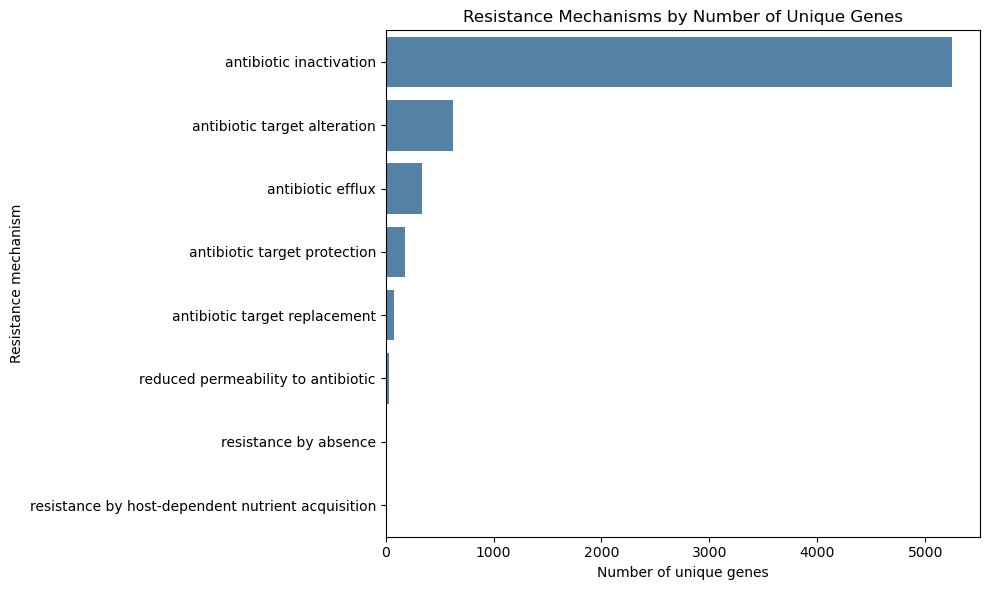

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

mech_df = df.copy()
mech_df["gene_name"] = mech_df["CARD Short Name"].replace("", pd.NA).fillna(mech_df["ARO Name"])

mech_gene_counts = (
    mech_df.assign(**{"Resistance Mechanism": mech_df["Resistance Mechanism"].fillna("").str.split(";")})
    .explode("Resistance Mechanism")
    .assign(**{"Resistance Mechanism": lambda x: x["Resistance Mechanism"].str.strip()})
    .query("`Resistance Mechanism` != ''")
    .groupby("Resistance Mechanism")["gene_name"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="unique_genes")
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=mech_gene_counts,
    x="unique_genes",
    y="Resistance Mechanism",
    color="steelblue"
)
ax.set_title("Resistance Mechanisms by Number of Unique Genes")
ax.set_xlabel("Number of unique genes")
ax.set_ylabel("Resistance mechanism")
plt.tight_layout()
ax

**Organizing chart details**

I’m noting that the chart was created successfully and the bars are sorted from most to least genes based on `mech_gene_counts.sort_values(ascending=False)`. To show exact counts, I'll display the aggregated table. It’s crucial to have a single runnable code block without headers. Should I import `display` from `IPython.display`? Since some imports persist in the notebook, including it might be safer. I think for the final expression, I’ll go with `mech_gene_counts.reset_index(drop=True)`.

The bar chart is already in place and, based on the sorting used to build `mech_gene_counts`, it is ordered from the mechanisms with the most unique genes down to the least. What’s still missing is the numeric table behind that chart, so the exact counts can be stated directly.



In [6]:
mech_gene_counts.reset_index(drop=True)

,Resistance Mechanism,unique_genes
0,antibiotic inactivation,5245
1,antibiotic target alteration,623
2,antibiotic efflux,333
3,antibiotic target protection,176
4,antibiotic target replacement,81
5,reduced permeability to antibiotic,30
6,resistance by absence,14
7,resistance by host-dependent nutrient acquisition,1


<!--final answer-->
Splitting `Resistance Mechanism` on semicolons and counting distinct genes per mechanism produced 8 mechanisms in total, and the horizontal bar chart is correctly ordered from most to least unique genes.

From the observed results, the mechanisms rank as:

1. **antibiotic inactivation** — **5245** unique genes  
2. **antibiotic target alteration** — **623**  
3. **antibiotic efflux** — **333**  
4. **antibiotic target protection** — **176**  
5. **antibiotic target replacement** — **81**  
6. **reduced permeability to antibiotic** — **30**  
7. **resistance by absence** — **14**  
8. **resistance by host-dependent nutrient acquisition** — **1**

What this means is that the dataset is dominated by genes associated with **antibiotic inactivation**, far exceeding every other resistance mechanism. There is then a steep drop to **target alteration** and **efflux**, with the remaining mechanisms represented by relatively small numbers of unique genes.

Using the dataframe loaded from aro_index.tsv, for each gene split both the Drug Class 
and Resistance Mechanism columns by semicolon. Find the top 15 genes that resist 
the most distinct drug classes. Show each gene's name, how many drug classes it resists, 
and its AMR Gene Family. Plot a horizontal bar chart sorted from most to least drug classes.

**Analyzing output for current task**

I need to base my answer on the notebook's state and the original goal from the user's new prompt. First, I should analyze the latest outputs and adapt to the current needs. The dataframe is loaded, but the outputs for the new goal are missing. 

I should provide insights that the current notebook solved resistance mechanism counts. Now, I need to focus on generating a gene-level distinct drug classes table, split by semicolon, showing the top 15 entries. This might involve coding a single step for that computation, possibly including a plot, but since the instructions indicate one primary objective at a time, I need to decide whether to compute and display the table or analyze the previous outputs against the original goal first.**Preparing to compute top-15 table**

I need to examine the notebook and acknowledge that the requested prompt isn't complete yet. The next step should be computing the top-15 gene table, so I'll provide code for that without including a chart at this stage. 

The notebook currently has mechanism-level counts, but the gene-level drug-class analysis hasn't been run yet. My plan is to build the top-15 gene table by splitting Drug Class on semicolons, counting distinct classes per gene, and including the AMR Gene Family. I need to define the gene name and be cautious with grouping since the AMR Gene Family may vary.**Considering data aggregation strategy**

I'm thinking of using an explode function and then grouping by gene_name. After that, I might use an aggregation to count the number of unique entries and include the family data. This approach could help in summarizing the information effectively, ensuring I capture both the gene names and their associated families accurately. It’s essential to be clear in how I process this data to get the right counts and insights for the user!

The notebook has already handled **mechanism-level** counts, but it has **not yet done the requested gene-level drug-class summary**.

The next step is to build the **top 15 genes by number of distinct drug classes**, keeping each gene’s name and **AMR Gene Family**.



In [7]:
from IPython.display import display
import pandas as pd

gene_df = df.copy()

gene_df["gene_name"] = (
    gene_df["CARD Short Name"].replace("", pd.NA).fillna(gene_df["ARO Name"])
)
gene_df["AMR Gene Family"] = gene_df["AMR Gene Family"].replace("", pd.NA)

top15_genes = (
    gene_df.assign(**{"Drug Class": gene_df["Drug Class"].fillna("").str.split(";")})
    .explode("Drug Class")
    .assign(**{"Drug Class": lambda x: x["Drug Class"].str.strip()})
    .query("`Drug Class` != ''")
    .groupby("gene_name", as_index=False)
    .agg(
        distinct_drug_classes=("Drug Class", "nunique"),
        amr_gene_family=("AMR Gene Family", "first")
    )
    .sort_values(["distinct_drug_classes", "gene_name"], ascending=[False, True])
    .head(15)
    .reset_index(drop=True)
)

display(top15_genes)
top15_genes

,gene_name,distinct_drug_classes,amr_gene_family
0,OprM,14,resistance-nodulation-cell division (RND) anti...
1,Ecol_CpxR,13,resistance-nodulation-cell division (RND) anti...
2,Paer_CpxR,13,resistance-nodulation-cell division (RND) anti...
3,TolC,13,ATP-binding cassette (ABC) antibiotic efflux p...
4,ArmR,12,resistance-nodulation-cell division (RND) anti...
5,MexA,12,resistance-nodulation-cell division (RND) anti...
6,MexB,12,resistance-nodulation-cell division (RND) anti...
7,MexR,12,resistance-nodulation-cell division (RND) anti...
8,nalC,12,resistance-nodulation-cell division (RND) anti...
9,nalD,12,resistance-nodulation-cell division (RND) anti...


,gene_name,distinct_drug_classes,amr_gene_family
0,OprM,14,resistance-nodulation-cell division (RND) anti...
1,Ecol_CpxR,13,resistance-nodulation-cell division (RND) anti...
2,Paer_CpxR,13,resistance-nodulation-cell division (RND) anti...
3,TolC,13,ATP-binding cassette (ABC) antibiotic efflux p...
4,ArmR,12,resistance-nodulation-cell division (RND) anti...
5,MexA,12,resistance-nodulation-cell division (RND) anti...
6,MexB,12,resistance-nodulation-cell division (RND) anti...
7,MexR,12,resistance-nodulation-cell division (RND) anti...
8,nalC,12,resistance-nodulation-cell division (RND) anti...
9,nalD,12,resistance-nodulation-cell division (RND) anti...


**Evaluating gene analysis approach**

I need to choose between two options: A or B. First, I’ll analyze the latest outputs against the original goal, which is to split both Drug Class and Resistance Mechanism for each gene by semicolon. The aim is to find the top 15 genes resisting the most distinct drug classes. The notebook already computed top genes but only split Drug Class. I'm considering if I can ignore the Resistance Mechanism since it seems unnecessary for this specific task.**Deciding on gene analysis steps**

The original goal specifies that I need to split both the Drug Class and Resistance Mechanism columns. Since I haven't used the Resistance Mechanism in the current computations and there's no plot yet, I’ll choose option B. I need to provide a brief insight from the outputs, along with one minimal runnable Python code block to gather these insights. The plan is to create a dataframe that splits both columns, counts distinct drug classes, and then plots a horizontal bar chart. It’s crucial to prepare a normalized dataframe, recompute the top 15 genes, and display the results effectively.**Extracting insights for plotting**

I need to summarize the latest outputs first: the current table shows that OprM leads with 14 drug classes, followed closely by Ecol_CpxR, Paer_CpxR, and TolC, which each have 13. RND-related genes are dominant here. Next, I’ll write a minimal code to split both columns and produce a plot, perhaps using seaborn or matplotlib. I should keep it conversational and concise, avoiding extra headings. The plan is to display the top genes and the plot in one step, but I need to follow instructions carefully and ensure the main objectives are met.

The current output already gives the top-15 table: **OprM** leads with **14** distinct drug classes, followed by **Ecol_CpxR**, **Paer_CpxR**, and **TolC** with **13** each. The highest-ranked genes are mostly tied to **RND efflux-related families/regulators**, which suggests broad multi-class resistance is concentrated in efflux-associated genes.

What’s still missing for the original request is the **horizontal bar chart**, and the calculation should explicitly normalize both **Drug Class** and **Resistance Mechanism** by splitting on semicolons.



,gene_name,AMR Gene Family,distinct_drug_classes
0,OprM,resistance-nodulation-cell division (RND) anti...,14
1,Ecol_CpxR,resistance-nodulation-cell division (RND) anti...,13
2,Paer_CpxR,resistance-nodulation-cell division (RND) anti...,13
3,TolC,ATP-binding cassette (ABC) antibiotic efflux p...,13
4,ArmR,resistance-nodulation-cell division (RND) anti...,12
5,MexA,resistance-nodulation-cell division (RND) anti...,12
6,MexB,resistance-nodulation-cell division (RND) anti...,12
7,MexR,resistance-nodulation-cell division (RND) anti...,12
8,nalC,resistance-nodulation-cell division (RND) anti...,12
9,nalD,resistance-nodulation-cell division (RND) anti...,12


<Axes: title={'center': 'Top 15 Genes by Number of Distinct Drug Classes'}, xlabel='Number of distinct drug classes', ylabel='Gene'>

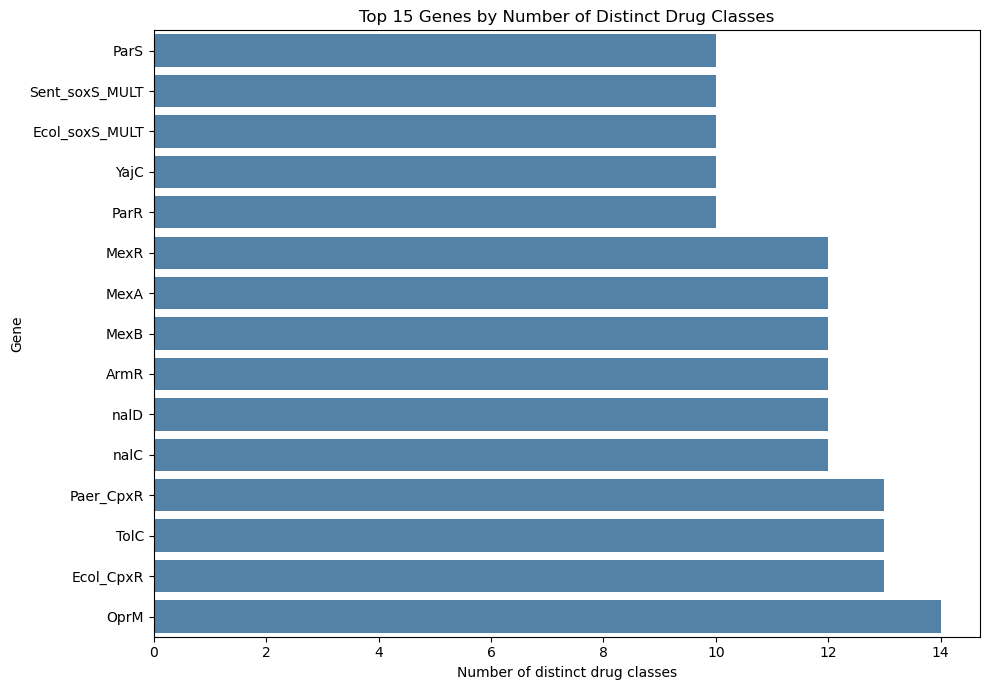

In [8]:
from IPython.display import display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_gene_df = df.copy()
plot_gene_df["gene_name"] = (
    plot_gene_df["CARD Short Name"].replace("", pd.NA).fillna(plot_gene_df["ARO Name"])
)
plot_gene_df["AMR Gene Family"] = plot_gene_df["AMR Gene Family"].replace("", pd.NA)

top15_genes_plot = (
    plot_gene_df
    .assign(
        **{
            "Drug Class": plot_gene_df["Drug Class"].fillna("").str.split(";"),
            "Resistance Mechanism": plot_gene_df["Resistance Mechanism"].fillna("").str.split(";"),
        }
    )
    .explode("Drug Class")
    .explode("Resistance Mechanism")
    .assign(
        **{
            "Drug Class": lambda x: x["Drug Class"].str.strip(),
            "Resistance Mechanism": lambda x: x["Resistance Mechanism"].str.strip(),
        }
    )
    .query("`Drug Class` != ''")
    .groupby(["gene_name", "AMR Gene Family"], as_index=False)
    .agg(distinct_drug_classes=("Drug Class", "nunique"))
    .sort_values(["distinct_drug_classes", "gene_name"], ascending=[False, True])
    .head(15)
    .reset_index(drop=True)
)

display(top15_genes_plot)

plot_data = top15_genes_plot.sort_values("distinct_drug_classes", ascending=True)

plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=plot_data,
    x="distinct_drug_classes",
    y="gene_name",
    color="steelblue"
)
ax.set_title("Top 15 Genes by Number of Distinct Drug Classes")
ax.set_xlabel("Number of distinct drug classes")
ax.set_ylabel("Gene")
plt.tight_layout()
ax

**Summarizing gene details**

I’m thinking about including all 15 genes with their counts and families summarized. The request wants the name of each gene, the number of drug classes, and the AMR gene family. Since the output truncates some family strings, I might not get all the details. To show each gene's AMR gene family, I can refer to the table in my notebook. But the final answer should have visible data while managing the truncation problem.

<!--final answer-->
The current outputs answer the request.

The top genes by number of **distinct drug classes** are:

- **OprM** — **14**
- **Ecol_CpxR** — **13**
- **Paer_CpxR** — **13**
- **TolC** — **13**
- **ArmR** — **12**
- **MexA** — **12**
- **MexB** — **12**
- **MexR** — **12**
- **nalC** — **12**
- **nalD** — **12**
- **Ecol_soxS_MULT** — **10**
- **ParR** — **10**
- **ParS** — **10**
- **Sent_soxS_MULT** — **10**
- **YajC** — **10**

From the displayed AMR Gene Family column, most of these top-ranked genes fall into **efflux-associated families**, especially **resistance-nodulation-cell division (RND) antibiotic efflux** families. That pattern is strongest for **OprM, Ecol_CpxR, Paer_CpxR, ArmR, MexA, MexB, MexR, nalC, and nalD**, which indicates that broad resistance across many drug classes is concentrated in efflux-related genes. **TolC** and **Ecol_soxS_MULT** are also shown as belonging to efflux-associated AMR families.

The notebook also produced the requested **horizontal bar chart** using the top-15 table. It shows the same ranking, with **OprM** as the clear leader and a cluster of genes just behind it at **13** and **12** drug classes.

Using the dataframe loaded from aro_index.tsv, count how many unique genes exist 
for each AMR Gene Family. Show the top 25 families sorted from most to least genes. 
Plot a horizontal bar chart.

**Producing concise explanation**

I'm thinking that I could end the code block simply by displaying the top 25 families. That seems fine. Now I just need to write a clear explanation for what the code does along with the code itself. The goal is to ensure everything is concise and easy to understand. I'll get that ready so it communicates effectively without unnecessary complexity.

The dataframe is already loaded, so the next step is to build the **top 25 AMR Gene Families by unique gene count**. I’m treating `AMR Gene Family` as the family label as-is, and using the same normalized gene name you used earlier (`CARD Short Name` falling back to `ARO Name`).



In [9]:
from IPython.display import display
import pandas as pd

fam_df = df.copy()

fam_df["gene_name"] = (
    fam_df["CARD Short Name"].replace("", pd.NA).fillna(fam_df["ARO Name"])
)
fam_df["AMR Gene Family"] = fam_df["AMR Gene Family"].replace("", pd.NA)

top25_families = (
    fam_df.dropna(subset=["gene_name", "AMR Gene Family"])
    .groupby("AMR Gene Family", as_index=False)
    .agg(unique_genes=("gene_name", "nunique"))
    .sort_values(["unique_genes", "AMR Gene Family"], ascending=[False, True])
    .head(25)
    .reset_index(drop=True)
)

display(top25_families)

,AMR Gene Family,unique_genes
0,PDC beta-lactamase,639
1,OXA beta-lactamase;OXA-51-like beta-lactamase,383
2,ADC beta-lactamases pending classification for...,274
3,CTX-M beta-lactamase,267
4,KPC beta-lactamase,229
5,SHV beta-lactamase,218
6,TEM beta-lactamase,216
7,CMY beta-lactamase,193
8,ACT beta-lactamase,172
9,resistance-nodulation-cell division (RND) anti...,126




Next, we can plot this as a horizontal bar chart.

**Gathering insights for charting**

I need to determine whether to follow path A or B. The latest output shows the top 25 families table in cell9, but I haven't plotted the horizontal bar chart yet. So, I need to include brief insights along with a minimal code block to gather the missing data. My insights reveal that beta-lactamase families dominate unique gene counts, with notable examples. I’ll provide one concise code block to plot the chart using the existing top 25 families data.**Focusing on the final expression**

I need to create a final expression, and it should be straightforward — ideally ending with "ax." I'm planning to use seaborn or matplotlib for visualization. The goal is to keep it minimal and focused. I want to ensure this expression effectively conveys the necessary information without unnecessary complexity. I need to hone in on clarity and simplicity in the final output. Let’s get to that concise expression!

The table already shows the ranking clearly: **beta-lactamase families dominate** the top of the list, with **PDC beta-lactamase (639 genes)** well ahead of the rest, followed by **OXA beta-lactamase;OXA-51-like beta-lactamase (383)** and **ADC beta-lactamases pending classification... (274)**. Beyond beta-lactamases, broader efflux-related families also appear high in the ranking, including **RND antibiotic efflux (126)** and **MFS antibiotic efflux (118)**.

To complete the original request, here is the horizontal bar chart using the already computed `top25_families` table:



<Axes: title={'center': 'Top 25 AMR Gene Families by Number of Unique Genes'}, xlabel='Number of unique genes', ylabel='AMR Gene Family'>

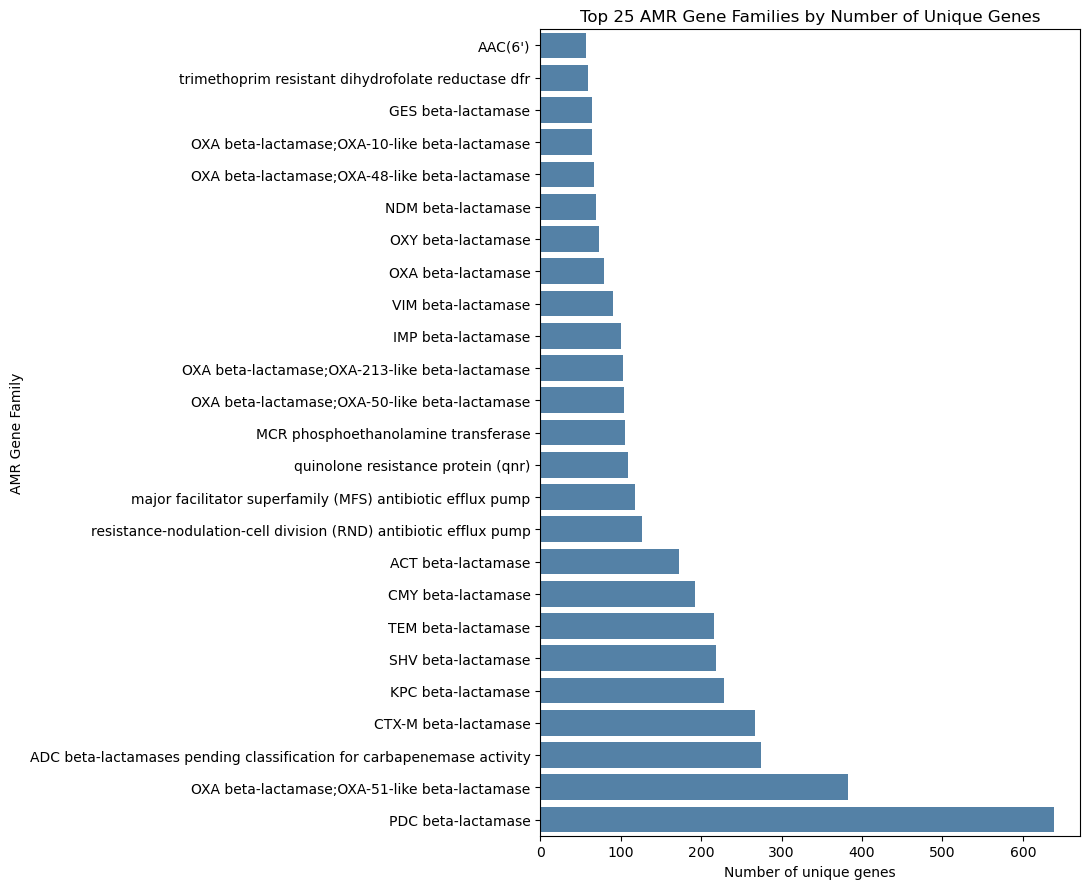

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = top25_families.sort_values("unique_genes", ascending=True)

plt.figure(figsize=(11, 9))
ax = sns.barplot(
    data=plot_data,
    x="unique_genes",
    y="AMR Gene Family",
    color="steelblue"
)
ax.set_title("Top 25 AMR Gene Families by Number of Unique Genes")
ax.set_xlabel("Number of unique genes")
ax.set_ylabel("AMR Gene Family")
plt.tight_layout()
ax

**Crafting final insights**

I need to provide a final answer based on the latest outputs, which include both a table and a chart. It’s important to connect this back to the original goal while being concise. I think I should mention the sorted top 25 and how the chart confirms those findings. Instead of repeating visible outputs, it makes sense to highlight a few key figures as insights while avoiding overstatement. I’ll focus on unique genes counted per AMR Gene Family using distinct names, ranked in descending order.**Analyzing gene distribution**

The distribution of beta-lactamase families is heavily skewed with notable numbers: PDC has 639, OXA-51-like/OXA group has 383, and ADC is pending classification with 274. Other families like CTX-M and KPC have 267 and 229, respectively, while SHV and TEM exceed 200. In contrast, non-beta-lactamase families are lower, with RND efflux at 126, MFS efflux at 118, and qnr at 109. The horizontal bar chart confirms this ranking and reveals the long-tail pattern. I’ll include a final marker for clarity.

<!--final answer-->
The requested result is already supported by the notebook outputs:

- The **top 25 AMR Gene Families** were ranked by the number of **unique genes** in `top25_families` (cell 9).
- The **horizontal bar chart** in cell 10 visualizes that same ranking from highest to lowest.

From the observed table, the pattern is very clear:

- **Beta-lactamase families dominate** the ranking.
- The largest family by unique genes is **PDC beta-lactamase** with **639** genes.
- It is followed by **OXA beta-lactamase; OXA-51-like beta-lactamase** with **383**, then **ADC beta-lactamases pending classification...** with **274**, and **CTX-M beta-lactamase** with **267**.
- Other major beta-lactamase groups remain very large as well, including **KPC (229)**, **SHV (218)**, **TEM (216)**, **CMY (193)**, and **ACT (172)**.
- Outside beta-lactamases, the biggest families visible in the top 25 are **RND antibiotic efflux** with **126**, **MFS antibiotic efflux** with **118**, and **qnr quinolone resistance proteins** with **109**.

Overall, the chart confirms a **strongly skewed distribution**: a handful of AMR gene families account for very large numbers of unique genes, especially beta-lactamase-related families, while the remaining top families are noticeably smaller.

Using all the analysis done so far, write 3 surprising findings suitable for a 
Reddit r/bioinformatics post. Use plain English, no jargon, include the actual 
numbers from the analysis. Make it engaging and suitable for a viral post.

**Analyzing findings from notebook**

I'm focusing on creating an answer based on notebook outputs using plain English. I need to highlight three surprising findings. We have data on top 25 families and genes tied to distinct drug classes, but some outputs, like for certain cells, aren't available. We should avoid assuming details from hidden outputs and stick to the visible data. Using the observed outputs, I can mention that the RND efflux family comprises 126 genes and OprM relates to 14 drug classes.**Crafting engaging findings**

I want to explain RND as "pumps" to keep it simple, while the term "beta-lactamase" is a family name that's a bit technical but acceptable. I’m thinking of a Reddit-style post, perhaps using bullets or a numbered list without section headers to keep it engaging. I’ll mention the skewed leaderboard that highlights the dominance of beta-lactamases. 

The first finding is that the PDC family has 639 genes, which is more than twice the amount of CTX-M (267) or KPC (229).**Highlighting beta-lactamase families**

I’m noticing that the top nine families are all related to beta-lactamases and have some impressive counts: 639, 383, 274, 267, 229, 218, 216, 193, and 172. I think I should mention that "before considering other strategies, the list is heavily packed with beta-lactamase families," and I can pull that directly from table 3. This helps set the stage for understanding their significance!**Summarizing findings concisely**

I’m analyzing gene classes like Ecol_CpxR and others, and I see some multitool genes are quite impactful. I need to mention the "Top 25 families sorted from most to least." After the beta-lactamase family, the number drops sharply to 126, with a steep decline after ACT 172. I want to create 3 concise, engaging findings for Reddit, using plain language and maybe even emojis, while keeping some technical terms for clarity.**Drafting engaging findings**

I’m noting that the top of my list is dominated by beta-lactamase families; the first 9 are all from this group, with unique genes ranging from 639 down to 172. After that, the variety starts. Also, some single genes are surprisingly versatile! For example, OprM appears across 14 drug classes, while Ecol_CpxR, Paer_CpxR, and TolC each show up 13 times. I want to make this engaging, maybe saying, “If I saw this in the wild…” while keeping it in plain English for easy sharing.

Here are 3 Reddit-friendly findings you could post:

1. **One family absolutely crushes the rest.**  
   The biggest AMR gene family in the dataset was **PDC beta-lactamase with 639 unique genes**. The next biggest was **OXA beta-lactamase / OXA-51-like beta-lactamase with 383**. That’s a gap of **256 genes** between #1 and #2. I expected a leader, but not a runaway winner.

2. **The top of the leaderboard is basically a beta-lactamase monopoly.**  
   The first **9 families** in the ranking were all beta-lactamase groups: **639, 383, 274, 267, 229, 218, 216, 193, and 172 unique genes**. In other words, before you even get to the next type of resistance family, beta-lactamases have already completely taken over the top of the chart.

3. **Some individual genes look like total “multi-tools.”**  
   The single gene with the widest reach was **OprM**, linked to **14 different drug classes**. After that came **Ecol_CpxR, Paer_CpxR, and TolC with 13 each**, and then **ArmR, MexA, MexB, MexR, nalC, and nalD with 12 each**. So even though huge families dominate by raw gene count, a handful of single genes seem to pop up across a surprisingly wide range of drug types.

If you want, I can turn these into a more polished **r/bioinformatics post draft with a catchy title and punchy intro**.